
# TP Series de Tiempo – Grupo 3 – Parte 2
## Comparación de Técnicas de Machine Learning y Deep Learning para Pronóstico de Series Temporales

Este notebook constituye la segunda parte del trabajo práctico e incorpora técnicas de ML y Deep Learning aplicadas al pronóstico de series temporales semanales. El análisis se complementa con los modelos estadísticos clásicos desarrollados en la Parte 1.

**Series analizadas:**
- Cortes de luz EPE Rosario — índice de búsqueda semanal (Google Trends, variable proxy)
- Temperatura media semanal en °C (Rosario)
- Humedad relativa media semanal en % (Rosario)

**Técnicas cubiertas:**

| Sección | Técnica |
|---------|---------|
| 1 | **SVR** – Support Vector Regression |
| 2 | **Darts** – Exponential Smoothing + N-BEATS |
| 3 | **NeuralProphet** – componente AR y estacionalidad anual |
| 4 | **LSTM** – red recurrente con ventana deslizante (TensorFlow/Keras) |
| 5 | **AutoML** – utilizando H2O  |
| 6 | **Comparación global** – RMSE, MAE y captura de variabilidad por técnica, serie y horizonte |

**Horizontes de pronóstico:** h = 1, 2 y 3 semanas

**División train/test:** 80% / 20%, consistente con la Parte 1

> La evaluación no se limita a métricas de error promedio (RMSE/MAE). Se incorporan indicadores de **captura de variabilidad** — como el ratio de desvíos estándar y la tasa de acierto en picos — dado que modelos con bajo error pueden estar prediciendo sistemáticamente la media sin detectar eventos extremos.

> Para el análisis estadístico clásico (SARIMA, SARIMAX, VAR) ver `TP_series_grupo3.ipynb`.



## Contexto y Problemática

Las tres series provienen de datos semanales de la ciudad de Rosario, Argentina (período 2020–2025):

1. **Cortes de luz (EPE Rosario):** Índice de búsqueda de Google Trends para "EPE Rosario" (escala 0–100) como proxy de los cortes de suministro eléctrico, dado que los datos oficiales no están disponibles públicamente. Presenta marcada estacionalidad anual asociada a las olas de calor veraniegas y alta variabilidad interanual.

2. **Temperatura:** Promedio semanal de temperatura en °C. Serie con comportamiento altamente estacional (ciclo anual muy definido) y baja varianza residual. Representa el driver climático principal de la demanda eléctrica.

3. **Humedad relativa:** Promedio semanal de humedad en %. Correlacionada negativamente con la temperatura en verano (baja humedad, alta temperatura). Complementa el análisis del comfort térmico.

**Motivación del enfoque ML/DL:** Los métodos estadísticos clásicos (SARIMA) de la Parte 1 capturan bien la estructura lineal y la estacionalidad. En esta parte exploramos si técnicas basadas en aprendizaje automático logran capturar patrones no lineales y mejorar el pronóstico, especialmente para la serie de cortes que presenta alta variabilidad y picos extremos.

In [3]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# SVR
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Darts
try:
    from darts import TimeSeries
    from darts.models import ExponentialSmoothing, NBEATSModel
    DARTS_OK = True
except ImportError:
    DARTS_OK = False
    print("⚠ darts no instalado – sección 2 requiere: pip install darts")

# NeuralProphet
try:
    from neuralprophet import NeuralProphet, set_log_level
    set_log_level("ERROR")
    NP_OK = True
except ImportError:
    NP_OK = False
    print("⚠ neuralprophet no instalado – sección 3 requiere: pip install neuralprophet")

# LSTM – TensorFlow
try:
    import tensorflow as tf
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import LSTM, Dense, Dropout
    from tensorflow.keras.callbacks import EarlyStopping
    TF_OK = True
except ImportError:
    TF_OK = False
    print("⚠ tensorflow no instalado – sección 4 requiere: pip install tensorflow")

# Reproducibilidad
SEED = 42
np.random.seed(SEED)
if TF_OK:
    tf.random.set_seed(SEED)

# Estilo
plt.rcParams.update({'figure.dpi': 100})
sns.set_theme(style='whitegrid', palette='muted')

print("✓ Configuración lista")

✓ Configuración lista


---
## Carga y preparación de datos

In [4]:
# Carga del dataset (mismo que Parte 1)
df = pd.read_csv('completo.csv', parse_dates=['Semana'], index_col='Semana')

# Normalizar decimales (separador coma → punto en Temp y Hum)
for col in ['Temp', 'Hum']:
    if df[col].dtype == object:
        df[col] = df[col].str.replace(',', '.').astype(float)

# Frecuencia semanal
df = df.asfreq('W-SUN')

print(f"Período   : {df.index[0].date()} → {df.index[-1].date()}")
print(f"Obs. total: {len(df)}")
print(f"\nColumnas  : {list(df.columns)}")
print(f"\nResumen estadístico:")
display(df.describe().round(2))

Período   : 2020-12-06 → 2025-12-07
Obs. total: 262

Columnas  : ['Cortes', 'Temp', 'Hum']

Resumen estadístico:


,Cortes,Temp,Hum
count,262.00,262.00,262.00
mean,24.25,18.69,66.44
std,10.10,6.47,12.64
min,11.00,5.28,30.42
25%,19.00,13.67,56.69
50%,22.00,18.43,69.26
75%,26.75,24.09,77.38
max,100.00,32.08,88.21


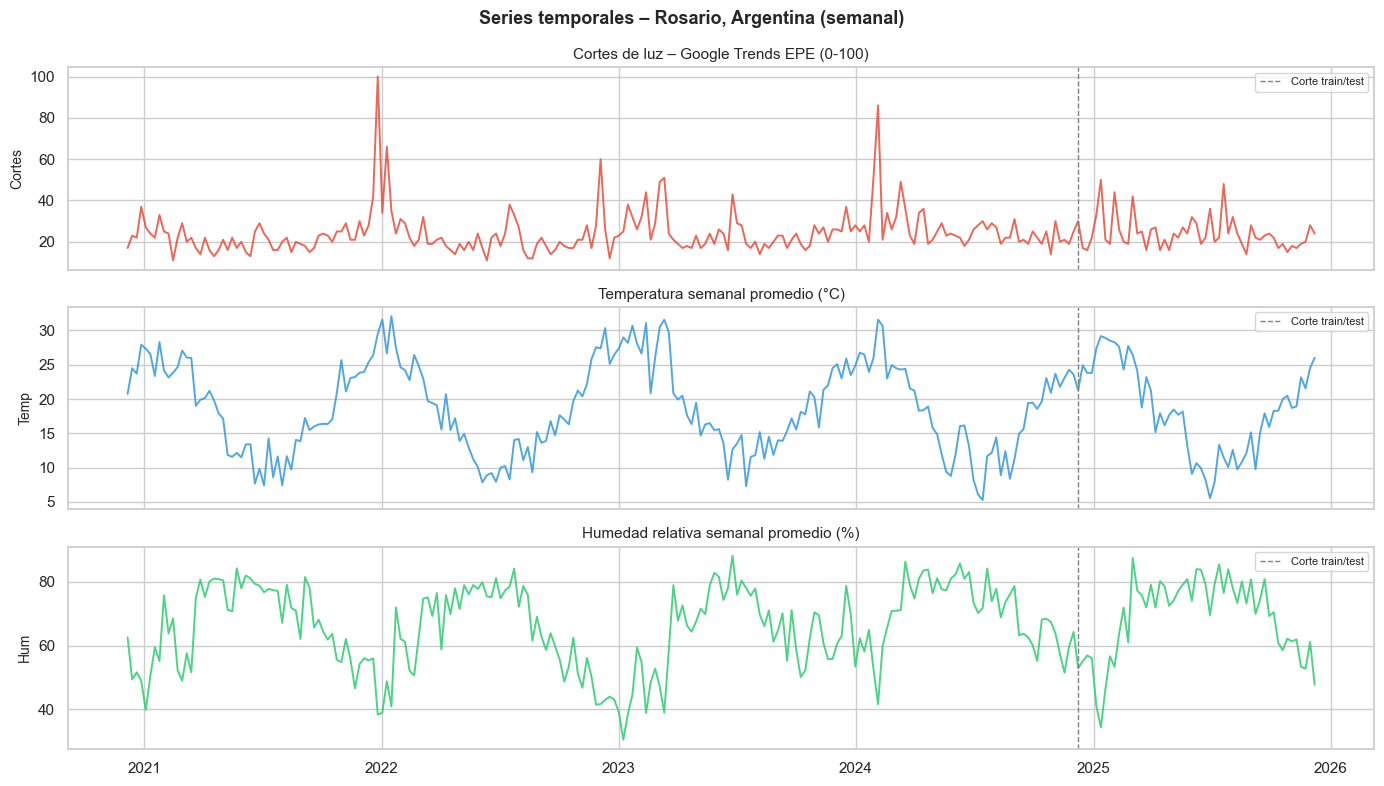

In [5]:
# Visualización de las tres series
fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)

config = [
    ('Cortes', 'Cortes de luz – Google Trends EPE (0-100)', '#e74c3c'),
    ('Temp',   'Temperatura semanal promedio (°C)',           '#3498db'),
    ('Hum',    'Humedad relativa semanal promedio (%)',        '#2ecc71'),
]

for ax, (col, title, color) in zip(axes, config):
    ax.plot(df.index, df[col], color=color, lw=1.4, alpha=0.85)
    ax.set_ylabel(col, fontsize=10)
    ax.set_title(title, fontsize=11)
    # Marcar corte train/test
    n_train = int(len(df) * 0.80)
    ax.axvline(df.index[n_train], color='gray', ls='--', lw=1, label='Corte train/test')
    ax.legend(fontsize=8)

plt.suptitle('Series temporales – Rosario, Argentina (semanal)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [6]:
# Parámetros globales del experimento
TEST_FRAC = 0.20
N         = len(df)
N_TRAIN   = int(N * (1 - TEST_FRAC))
N_TEST    = N - N_TRAIN
HORIZONS  = [1, 2, 3]   # semanas hacia adelante

SERIES = {
    'Cortes': df['Cortes'].copy(),
    'Temp'  : df['Temp'].copy(),
    'Hum'   : df['Hum'].copy(),
}

print(f"Total: {N} obs  |  Train: {N_TRAIN}  |  Test: {N_TEST}")
print(f"Horizontes: {HORIZONS} semanas")

# Almacén global de resultados: {técnica: {serie: {h: {'rmse':..., 'mae':...}}}}
all_results = {}


# ── Helpers ─────────────────────────────────────────────────────────────────
def compute_metrics(y_true, y_pred):
    """Retorna (RMSE, MAE)."""
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    return rmse, mae


def print_metrics_table(technique_results, technique_name):
    """Imprime y retorna DataFrame con RMSE/MAE por serie y horizonte."""
    rows = []
    for serie, h_dict in technique_results.items():
        for h, m in h_dict.items():
            rows.append({'Técnica': technique_name, 'Serie': serie, 'h': h,
                         'RMSE': round(m['rmse'], 4), 'MAE': round(m['mae'], 4)})
    df_tbl = pd.DataFrame(rows)
    pivot  = df_tbl.pivot_table(index=['Serie', 'h'], columns='Técnica', values=['RMSE', 'MAE'])
    print(f"\n{'='*55}")
    print(f"  {technique_name} – Métricas por serie y horizonte")
    print(f"{'='*55}")
    print(pivot.to_string())
    return df_tbl

Total: 262 obs  |  Train: 209  |  Test: 53
Horizontes: [1, 2, 3] semanas


---
## 1. Support Vector Regression (SVR)

### Motivación

SVR extiende las máquinas de soporte vectorial al problema de regresión. Es adecuado para series temporales
porque:
- Maneja relaciones **no lineales** mediante el kernel RBF (distancia radial en feature space).
- Es **robusto a outliers**: minimiza el error solo fuera del tubo ε (insensitive loss).
- Funciona bien con **datasets medianos** (< 1000 obs), sin requerir grandes volúmenes de datos.

### Estrategia: Direct Multi-Step Forecasting

Se reformula el problema como aprendizaje supervisado mediante *lag features*. Para cada horizonte h se
entrena un **modelo independiente** (estrategia *direct*):

$$\hat{y}_{t+h} = f_h(y_t, y_{t-1}, \ldots, y_{t-k})$$

### Features utilizados

| Feature | Descripción |
|---------|-------------|
| `lag_1 … lag_4` | Valores rezagados 1 a 4 semanas |
| `lag_8`, `lag_52` | Rezago bimestral y anual (estacionalidad) |
| `roll_mean_4/8` | Media móvil 4 y 8 semanas (tendencia local) |
| `roll_std_4/8` | Desviación estándar 4 y 8 semanas (volatilidad) |

### Hiperparámetros (GridSearchCV con TimeSeriesSplit)

| Parámetro | Rango |
|-----------|-------|
| `C` | 0.1 · 1 · 10 · 100 |
| `epsilon` | 0.01 · 0.1 · 0.5 · 1.0 |
| `kernel` | RBF (gamma='scale') |

In [12]:
# ── Funciones SVR ────────────────────────────────────────────────────────────

def create_svr_features(series, lags=[1, 2, 3, 4, 8, 52]):
    """
    Construye DataFrame de features con lags y estadísticas rolling.
    Todos los features son causales (solo usan información pasada).
    """
    data = {}
    s = series.copy()
    for lag in lags:
        data[f'lag_{lag}'] = s.shift(lag)
    # Rolling sobre valores pasados (shift(1) para causalidad estricta)
    data['roll_mean_4'] = s.shift(1).rolling(4).mean()
    data['roll_std_4']  = s.shift(1).rolling(4).std()
    data['roll_mean_8'] = s.shift(1).rolling(8).mean()
    data['roll_std_8']  = s.shift(1).rolling(8).std()
    return pd.DataFrame(data, index=series.index)


def train_svr_multistep(series, horizons=None, test_frac=TEST_FRAC):
    """
    Entrena un SVR por horizonte h (estrategia direct).
    Retorna dict {h: {'rmse', 'mae', 'best_params', 'y_test', 'y_pred', 'index'}}.
    """
    if horizons is None:
        horizons = HORIZONS

    feat_df = create_svr_features(series)
    results = {}

    for h in horizons:
        # Target: valor h pasos adelante
        target = series.shift(-h).rename('target')
        data   = pd.concat([feat_df, target], axis=1).dropna()

        X = data.drop('target', axis=1)
        y = data['target']

        n_tr = int(len(X) * (1 - test_frac))
        X_tr, X_te = X.iloc[:n_tr], X.iloc[n_tr:]
        y_tr, y_te = y.iloc[:n_tr], y.iloc[n_tr:]

        # Escalado obligatorio para SVR
        sc_X = StandardScaler()
        sc_y = StandardScaler()
        X_tr_sc = sc_X.fit_transform(X_tr)
        X_te_sc = sc_X.transform(X_te)
        y_tr_sc = sc_y.fit_transform(y_tr.values.reshape(-1, 1)).ravel()

        # Búsqueda de hiperparámetros con validación cruzada temporal
        param_grid = {
            'C'      : [0.1, 1, 10, 100],
            'epsilon': [0.01, 0.1, 0.5, 1.0],
        }
        tscv = TimeSeriesSplit(n_splits=3)
        gs   = GridSearchCV(
            SVR(kernel='rbf', gamma='scale'), param_grid,
            cv=tscv, scoring='neg_root_mean_squared_error',
            n_jobs=-1, verbose=0
        )
        gs.fit(X_tr_sc, y_tr_sc)

        # Predicción en test
        y_pred_sc = gs.predict(X_te_sc)
        y_pred    = sc_y.inverse_transform(y_pred_sc.reshape(-1, 1)).ravel()

        rmse, mae = compute_metrics(y_te.values, y_pred)
        results[h] = {
            'rmse': rmse, 'mae': mae,
            'best_params': gs.best_params_,
            'y_test': y_te.values, 'y_pred': y_pred,
            'index': y_te.index,
        }
        print(f"  h={h}  →  RMSE={rmse:.4f}  MAE={mae:.4f}  "
              f"params={gs.best_params_}")
    return results


def plot_svr(series_name, svr_res):
    """Gráfico de predicciones vs reales para cada horizonte."""
    fig, axes = plt.subplots(1, len(HORIZONS), figsize=(15, 4), sharey=True)
    for ax, h in zip(axes, HORIZONS):
        r = svr_res[h]
        ax.plot(r['index'], r['y_test'], label='Real',    color='#2c3e50', lw=1.5)
        ax.plot(r['index'], r['y_pred'], label='SVR pred', color='#e74c3c', lw=1.5, ls='--')
        ax.set_title(f'h = {h} sem  |  RMSE = {r["rmse"]:.3f}', fontsize=10)
        ax.legend(fontsize=8)
        ax.tick_params(axis='x', rotation=30)
    fig.suptitle(f'SVR – {series_name}', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

print("✓ Funciones SVR definidas")
# ── Métricas de variabilidad ──────────────────────────────────────────────────
def add_variability_metrics(results: dict) -> dict:
    """
    Agrega métricas de captura de variabilidad a un dict de resultados
    con estructura {h: {'y_test', 'y_pred', ...}}.
    Opera in-place y también retorna el dict.
    """
    for h, r in results.items():
        y_true = r['y_test']
        y_pred = r['y_pred']

        # Ratio de desvíos estándar (> 1 → sobreestima variabilidad, < 1 → subamortiguado)
        std_ratio = np.std(y_pred) / np.std(y_true) if np.std(y_true) > 0 else np.nan

        # Tasa de acierto en picos: % de valores reales en el cuartil superior
        # que el modelo también predice en el cuartil superior
        q75 = np.quantile(y_true, 0.75)
        peak_mask = y_true >= q75
        if peak_mask.sum() > 0:
            peak_hit_rate = np.mean(y_pred[peak_mask] >= q75)
        else:
            peak_hit_rate = np.nan

        r['std_ratio']     = round(std_ratio, 4)
        r['peak_hit_rate'] = round(peak_hit_rate, 4)

    return results


✓ Funciones SVR definidas


### 1.1. SVR – Cortes de luz (EPE Rosario)

  h=1  →  RMSE=6.7868  MAE=5.3528  params={'C': 1, 'epsilon': 0.5}
  h=2  →  RMSE=6.8908  MAE=5.2686  params={'C': 1, 'epsilon': 0.5}
  h=3  →  RMSE=6.7650  MAE=5.2215  params={'C': 1, 'epsilon': 0.5}


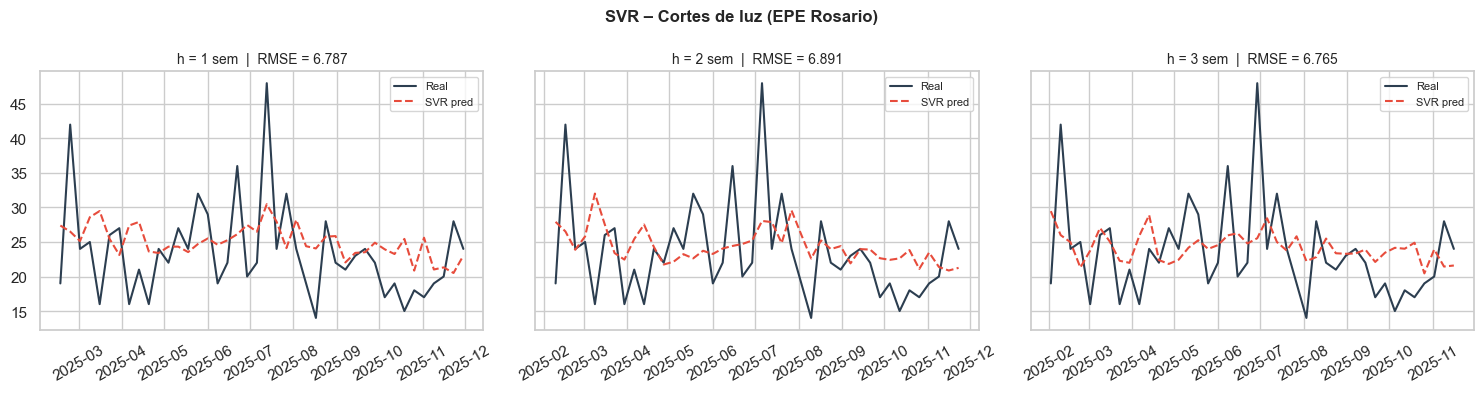

In [15]:
svr_cortes = add_variability_metrics(train_svr_multistep(SERIES['Cortes']))
plot_svr('Cortes de luz (EPE Rosario)', svr_cortes)

### 1.2. SVR – Temperatura (°C)

  h=1  →  RMSE=3.0934  MAE=2.3776  params={'C': 1, 'epsilon': 0.01}
  h=2  →  RMSE=3.5910  MAE=2.7317  params={'C': 1, 'epsilon': 0.01}
  h=3  →  RMSE=3.7071  MAE=2.9266  params={'C': 1, 'epsilon': 0.1}


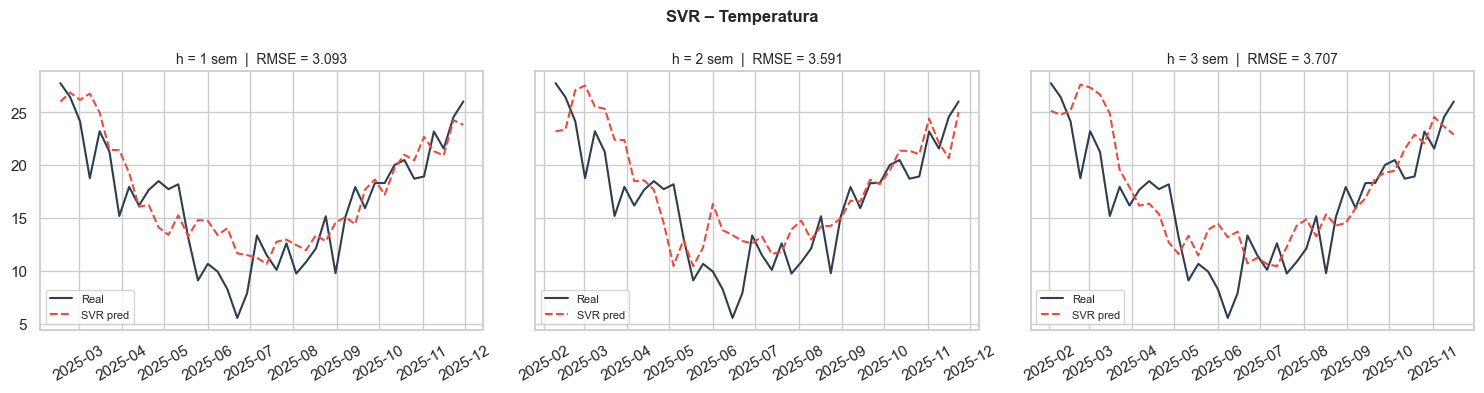

In [19]:
svr_temp = add_variability_metrics(train_svr_multistep(SERIES['Temp']))
plot_svr('Temperatura', svr_temp)

### 1.3. SVR – Humedad relativa (%)

  h=1  →  RMSE=9.0505  MAE=7.0833  params={'C': 100, 'epsilon': 0.5}
  h=2  →  RMSE=6.7337  MAE=5.1221  params={'C': 1, 'epsilon': 0.5}
  h=3  →  RMSE=8.5510  MAE=6.4955  params={'C': 10, 'epsilon': 0.5}


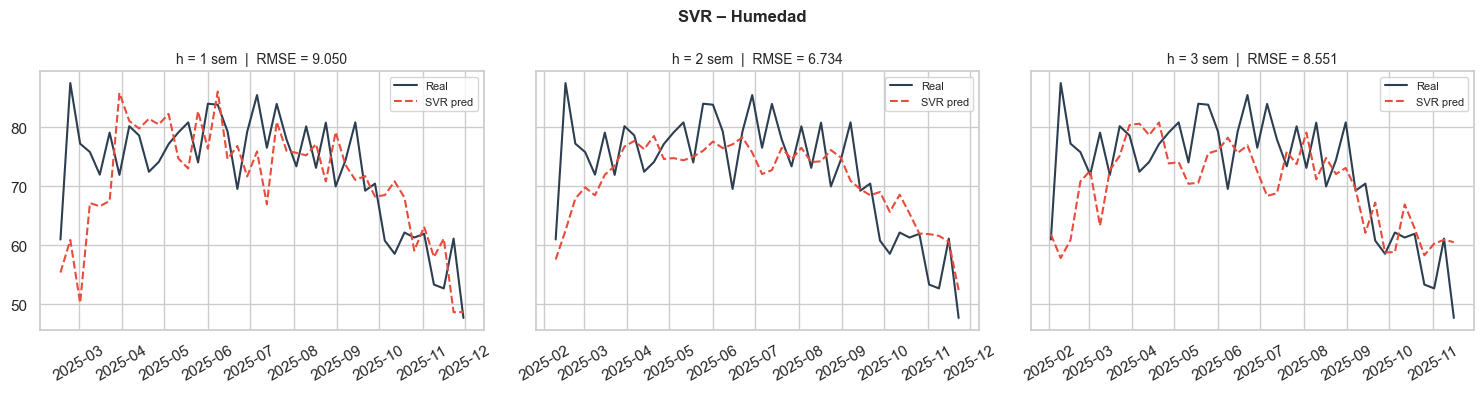

In [20]:
svr_hum = add_variability_metrics(train_svr_multistep(SERIES['Hum']))
plot_svr('Humedad', svr_hum)

In [21]:
# ── Tabla de métricas SVR ─────────────────────────────────────────────────────
rows = []
for serie_name, svr_res in [('Cortes', svr_cortes),
                              ('Temperatura', svr_temp),
                              ('Humedad', svr_hum)]:
    for h, r in svr_res.items():
        rows.append({
            'Serie'        : serie_name,
            'Horizonte (h)': h,
            'RMSE'         : round(r['rmse'], 4),
            'MAE'          : round(r['mae'], 4),
            'Std Ratio'    : r['std_ratio'],
            'Peak Hit Rate': r['peak_hit_rate'],
        })

df_svr_metrics = pd.DataFrame(rows)
display(df_svr_metrics.style
        .format({'RMSE': '{:.4f}', 'MAE': '{:.4f}',
                 'Std Ratio': '{:.4f}', 'Peak Hit Rate': '{:.2%}'})
        .background_gradient(subset=['RMSE', 'MAE'], cmap='Reds')
        .background_gradient(subset=['Std Ratio'], cmap='RdYlGn', vmin=0.5, vmax=1.5)
        .background_gradient(subset=['Peak Hit Rate'], cmap='Greens')
        .set_caption('Métricas SVR – por serie y horizonte'))


,Serie,Horizonte (h),RMSE,MAE,Std Ratio,Peak Hit Rate
0,Cortes,1,6.7868,5.3528,0.3345,36.36%
1,Cortes,2,6.8908,5.2686,0.3525,27.27%
2,Cortes,3,6.7650,5.2215,0.2961,27.27%
3,Temperatura,1,3.0934,2.3776,0.8790,90.91%
4,Temperatura,2,3.5910,2.7317,0.8843,90.91%
5,Temperatura,3,3.7071,2.9266,0.9457,81.82%
6,Humedad,1,9.0505,7.0833,1.0042,27.27%
7,Humedad,2,6.7337,5.1221,0.6564,0.00%
8,Humedad,3,8.5510,6.4955,0.7290,0.00%


Los resultados del SVR muestran un comportamiento muy dispar según la serie. Para **Temperatura**, el modelo es el más sólido de los tres: el error crece moderadamente con el horizonte (RMSE de 3.09 a 3.71) y el Std Ratio se mantiene cercano a 1 en todos los horizontes, lo que indica que el modelo no aplana la señal; el Peak Hit Rate por encima del 80% confirma que detecta bien los episodios cálidos extremos. En **Humedad**, los resultados son mixtos: el horizonte h=1 logra un Std Ratio casi perfecto (1.00), pero el Peak Hit Rate cae a 27% ya en h=1 y llega a 0% para h=2 y h=3, evidenciando que el modelo captura la dispersión global de la serie pero falla sistemáticamente en identificar los picos de mayor humedad. El caso más problemático es el de **Cortes de luz**: el RMSE se estabiliza alrededor de 6.8 en los tres horizontes —lo que podría parecer consistencia— pero el Std Ratio de apenas 0.30–0.35 delata que el SVR está prediciendo esencialmente la media de la serie, sin capturar su variabilidad; el Peak Hit Rate entre 27% y 36% confirma que los picos de búsqueda, que son precisamente el evento de interés, quedan casi sin detectar. Este comportamiento es esperable dado que los datos de Google Trends son una proxy ruidosa con estructura temporal débil.

In [22]:
# Mejores hiperparámetros encontrados por GridSearch
print("\nMejores hiperparámetros SVR:")
for serie_key, svr_res in [('Cortes', svr_cortes), ('Temp', svr_temp), ('Hum', svr_hum)]:
    for h in HORIZONS:
        print(f"  {serie_key:8s}  h={h}  →  {svr_res[h]['best_params']}")


Mejores hiperparámetros SVR:
  Cortes    h=1  →  {'C': 1, 'epsilon': 0.5}
  Cortes    h=2  →  {'C': 1, 'epsilon': 0.5}
  Cortes    h=3  →  {'C': 1, 'epsilon': 0.5}
  Temp      h=1  →  {'C': 1, 'epsilon': 0.01}
  Temp      h=2  →  {'C': 1, 'epsilon': 0.01}
  Temp      h=3  →  {'C': 1, 'epsilon': 0.1}
  Hum       h=1  →  {'C': 100, 'epsilon': 0.5}
  Hum       h=2  →  {'C': 1, 'epsilon': 0.5}
  Hum       h=3  →  {'C': 10, 'epsilon': 0.5}


---
## 2. Darts – Modelos Clásicos y Neurales

**Darts** es una librería Python que unifica la API para modelos estadísticos y neurales de series temporales.

En este trabajo aplicamos dos modelos representativos:

1. **ExponentialSmoothing (Holt-Winters aditivo)** – baseline estacional clásico, período S = 52 semanas.
2. **N-BEATS** – red neuronal basada en bloques con componentes de tendencia y estacionalidad interpretables.

Se selecciona el mejor modelo por horizonte según RMSE en test.

In [ ]:
# ── Funciones Darts ──────────────────────────────────────────────────────────

if not DARTS_OK:
    print("⚠ Saltando sección Darts (librería no disponible)")
else:
    def to_darts_ts(series):
        """Convierte pd.Series a darts.TimeSeries con frecuencia semanal."""
        s = series.copy()
        s.index = pd.DatetimeIndex(s.index)
        return TimeSeries.from_series(s, freq='W')

    def eval_darts_model(model, train_ts, val_ts, horizons=None):
        """Entrena un modelo Darts y evalúa en cada horizonte."""
        if horizons is None:
            horizons = HORIZONS
        model.fit(train_ts)
        results = {}
        for h in horizons:
            pred       = model.predict(h)
            y_true_arr = val_ts[-h:].values().flatten()
            y_pred_arr = pred.values().flatten()
            min_len    = min(len(y_true_arr), len(y_pred_arr))
            rmse, mae  = compute_metrics(y_true_arr[:min_len], y_pred_arr[:min_len])
            results[h] = {'rmse': rmse, 'mae': mae,
                          'y_pred': y_pred_arr[:min_len], 'y_true': y_true_arr[:min_len]}
        return results

    def run_darts_series(series, series_name):
        """Aplica ExponentialSmoothing y NBEATS. Retorna mejores métricas y resultados completos."""
        ts      = to_darts_ts(series)
        n_train = int(len(ts) * (1 - TEST_FRAC))
        train_ts = ts[:n_train]
        val_ts   = ts[n_train:]
        print(f"\n  {series_name}:  train={len(train_ts)} | test={len(val_ts)}")

        # Modelo 1: Exponential Smoothing (Holt-Winters aditivo, S=52)
        es_model = ExponentialSmoothing(seasonal_periods=52, trend=True, seasonal='additive')
        es_res   = eval_darts_model(es_model, train_ts, val_ts)
        print(f"    ExpSmoothing → " +
              " | ".join([f"h={h}: RMSE={es_res[h]['rmse']:.4f}" for h in HORIZONS]))

        # Modelo 2: N-BEATS (entrenamiento liviano)
        nbeats_model = NBEATSModel(
            input_chunk_length=16,
            output_chunk_length=3,
            n_epochs=50,
            random_state=SEED,
            pl_trainer_kwargs={"enable_progress_bar": False},
        )
        nbeats_res = eval_darts_model(nbeats_model, train_ts, val_ts)
        print(f"    N-BEATS      → " +
              " | ".join([f"h={h}: RMSE={nbeats_res[h]['rmse']:.4f}" for h in HORIZONS]))

        # Mejor modelo por horizonte
        best = {}
        for h in HORIZONS:
            if es_res[h]['rmse'] <= nbeats_res[h]['rmse']:
                best[h] = {**es_res[h], 'model': 'ExpSmoothing'}
            else:
                best[h] = {**nbeats_res[h], 'model': 'NBEATS'}
            print(f"    Mejor h={h}: {best[h]['model']}  RMSE={best[h]['rmse']:.4f}")

        return best, {'ExponentialSmoothing': es_res, 'NBEATS': nbeats_res}

    print("✓ Funciones Darts definidas")

### 2.1. Darts – Cortes de luz (EPE Rosario)

In [ ]:
if DARTS_OK:
    print("━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")
    print(f"  DARTS – Cortes de luz (EPE Rosario)")
    print("━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")
    darts_cortes, darts_cortes_all = run_darts_series(SERIES['Cortes'], 'Cortes de luz (EPE Rosario)')

### 2.2. Darts – Temperatura

In [ ]:
if DARTS_OK:
    print("━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")
    print(f"  DARTS – Temperatura")
    print("━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")
    darts_temp, darts_temp_all = run_darts_series(SERIES['Temp'], 'Temperatura')

### 2.3. Darts – Humedad relativa

In [ ]:
if DARTS_OK:
    print("━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")
    print(f"  DARTS – Humedad relativa")
    print("━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")
    darts_hum, darts_hum_all = run_darts_series(SERIES['Hum'], 'Humedad relativa')

In [ ]:
if DARTS_OK:
    all_results['Darts'] = {
        'Cortes': {h: {'rmse': darts_cortes[h]['rmse'], 'mae': darts_cortes[h]['mae']} for h in HORIZONS},
        'Temp'  : {h: {'rmse': darts_temp[h]['rmse'],   'mae': darts_temp[h]['mae']}   for h in HORIZONS},
        'Hum'   : {h: {'rmse': darts_hum[h]['rmse'],    'mae': darts_hum[h]['mae']}    for h in HORIZONS},
    }
    df_darts = print_metrics_table(all_results['Darts'], 'Darts')

---
## 3. NeuralProphet

**NeuralProphet** extiende Facebook Prophet combinando:
- Descomposición clásica (tendencia + estacionalidad)
- Componente **autorregresivo** (`n_lags`) entrenado con una red feedforward

Configuración utilizada:
- `n_lags = 4` (AR de orden 4)
- `yearly_seasonality = True` (ciclo anual, clave para las 3 series)
- `loss_func = 'Huber'` (robusto a valores extremos en Cortes EPE)
- `n_forecasts = h` (pronóstico directo de h pasos)

In [ ]:
# ── Funciones NeuralProphet ──────────────────────────────────────────────────

if not NP_OK:
    print("⚠ Saltando sección NeuralProphet (librería no disponible)")
else:
    def prep_prophet(series):
        """Formato requerido por NeuralProphet: columnas 'ds' e 'y'."""
        df_p = pd.DataFrame({'ds': series.index, 'y': series.values})
        df_p['ds'] = pd.to_datetime(df_p['ds'])
        return df_p.reset_index(drop=True)

    def run_neuralprophet(series, series_name, horizons=None):
        """Entrena NeuralProphet y evalúa para cada horizonte."""
        if horizons is None:
            horizons = HORIZONS
        df_p    = prep_prophet(series)
        n_train = int(len(df_p) * (1 - TEST_FRAC))
        train_df = df_p.iloc[:n_train].copy()
        test_df  = df_p.iloc[n_train:].copy()
        results  = {}

        for h in horizons:
            m = NeuralProphet(
                n_lags=4,
                n_forecasts=h,
                yearly_seasonality=True,
                weekly_seasonality=False,
                daily_seasonality=False,
                epochs=100,
                learning_rate=0.01,
                loss_func='Huber',
            )
            m.fit(train_df, freq='W', progress='none')

            # Pronóstico: se predice sobre el período de test
            future   = m.make_future_dataframe(train_df, periods=h,
                                               n_historic_predictions=len(test_df))
            forecast = m.predict(future)

            # Extraer columna de predicción h-steps ahead
            pred_col = f'yhat{h}' if f'yhat{h}' in forecast.columns else                        [c for c in forecast.columns if c.startswith('yhat')][-1]

            y_pred = forecast[pred_col].dropna().values[-len(test_df):]
            y_true = test_df['y'].values[-len(y_pred):]
            min_len = min(len(y_true), len(y_pred))

            rmse, mae = compute_metrics(y_true[:min_len], y_pred[:min_len])
            results[h] = {'rmse': rmse, 'mae': mae}
            print(f"  {series_name:30s}  h={h}  RMSE={rmse:.4f}  MAE={mae:.4f}")

        return results

    print("✓ Funciones NeuralProphet definidas")

### 3.1. NeuralProphet – Cortes de luz (EPE Rosario)

In [ ]:
if NP_OK:
    print("━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")
    print(f"  NeuralProphet – Cortes de luz (EPE Rosario)")
    print("━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")
    np_cortes = run_neuralprophet(SERIES['Cortes'], 'Cortes de luz (EPE Rosario)')

### 3.2. NeuralProphet – Temperatura

In [ ]:
if NP_OK:
    print("━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")
    print(f"  NeuralProphet – Temperatura")
    print("━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")
    np_temp = run_neuralprophet(SERIES['Temp'], 'Temperatura')

### 3.3. NeuralProphet – Humedad relativa

In [ ]:
if NP_OK:
    print("━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")
    print(f"  NeuralProphet – Humedad relativa")
    print("━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")
    np_hum = run_neuralprophet(SERIES['Hum'], 'Humedad relativa')

In [ ]:
if NP_OK:
    all_results['NeuralProphet'] = {
        'Cortes': np_cortes,
        'Temp'  : np_temp,
        'Hum'   : np_hum,
    }
    df_np = print_metrics_table(all_results['NeuralProphet'], 'NeuralProphet')

---
## 4. LSTM (TensorFlow / Keras)

Las redes **LSTM** (Long Short-Term Memory) son especialmente adecuadas para series temporales por su
capacidad de capturar dependencias temporales de largo alcance mediante sus mecanismos de gates.

**Arquitectura:**
```
Input: (WINDOW_SIZE=8, 1)
  → LSTM(64, return_sequences=True)
  → Dropout(0.2)
  → LSTM(32)
  → Dense(h)      # salida directa de h pasos
```

**Estrategia:** Una sola red predice los h pasos de una vez (multi-output directo).
**Early stopping:** Patience = 10 sobre pérdida de validación (10% del train).
**Escalado:** StandardScaler antes de entrenar, desescalado en la salida.

In [ ]:
# ── Funciones LSTM ───────────────────────────────────────────────────────────

if not TF_OK:
    print("⚠ Saltando sección LSTM (TensorFlow no disponible)")
else:
    WINDOW_SIZE = 8

    def create_sequences(vals, window, horizon):
        """Genera pares (X, y) con ventana deslizante."""
        X, y = [], []
        for i in range(len(vals) - window - horizon + 1):
            X.append(vals[i : i + window])
            y.append(vals[i + window : i + window + horizon])
        return np.array(X), np.array(y)

    def build_lstm_model(window, horizon):
        model = Sequential([
            LSTM(64, return_sequences=True, input_shape=(window, 1)),
            Dropout(0.2),
            LSTM(32),
            Dense(horizon),
        ])
        model.compile(optimizer='adam', loss='mse')
        return model

    def run_lstm(series, series_name, horizons=None):
        """Entrena LSTM y evalúa para cada horizonte h."""
        if horizons is None:
            horizons = HORIZONS
        sc   = StandardScaler()
        vals = sc.fit_transform(series.values.reshape(-1, 1)).flatten()
        results = {}

        for h in horizons:
            X, y = create_sequences(vals, WINDOW_SIZE, h)
            X    = X.reshape(X.shape[0], X.shape[1], 1)

            n_tr = int(len(X) * (1 - TEST_FRAC))
            X_tr, X_te = X[:n_tr], X[n_tr:]
            y_tr, y_te = y[:n_tr], y[n_tr:]

            tf.random.set_seed(SEED)
            model = build_lstm_model(WINDOW_SIZE, h)
            es    = EarlyStopping(monitor='val_loss', patience=10,
                                  restore_best_weights=True)
            model.fit(X_tr, y_tr, validation_split=0.1,
                      epochs=150, batch_size=16,
                      callbacks=[es], verbose=0)

            y_pred_sc = model.predict(X_te, verbose=0)
            # Desescalar el último paso del horizonte
            y_pred = sc.inverse_transform(
                y_pred_sc[:, -1].reshape(-1, 1)).flatten()
            y_true = sc.inverse_transform(
                y_te[:, -1].reshape(-1, 1)).flatten()

            rmse, mae = compute_metrics(y_true, y_pred)
            results[h] = {'rmse': rmse, 'mae': mae}
            print(f"  {series_name:30s}  h={h}  RMSE={rmse:.4f}  MAE={mae:.4f}")

        return results

    print("✓ Funciones LSTM definidas")

### 4.1. LSTM – Cortes de luz (EPE Rosario)

In [ ]:
if TF_OK:
    print("━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")
    print(f"  LSTM – Cortes de luz (EPE Rosario)")
    print("━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")
    lstm_cortes = run_lstm(SERIES['Cortes'], 'Cortes de luz (EPE Rosario)')

### 4.2. LSTM – Temperatura

In [ ]:
if TF_OK:
    print("━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")
    print(f"  LSTM – Temperatura")
    print("━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")
    lstm_temp = run_lstm(SERIES['Temp'], 'Temperatura')

### 4.3. LSTM – Humedad relativa

In [ ]:
if TF_OK:
    print("━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")
    print(f"  LSTM – Humedad relativa")
    print("━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")
    lstm_hum = run_lstm(SERIES['Hum'], 'Humedad relativa')

In [ ]:
if TF_OK:
    all_results['LSTM'] = {
        'Cortes': lstm_cortes,
        'Temp'  : lstm_temp,
        'Hum'   : lstm_hum,
    }
    df_lstm = print_metrics_table(all_results['LSTM'], 'LSTM')

---
## 5. Comparación Global de Técnicas

Se consolidan RMSE y MAE para todas las técnicas evaluadas sobre las 3 series y los 3 horizontes.
El **mejor modelo por (serie, horizonte)** se marca en negrita.

In [ ]:
# Construir DataFrame de comparación
rows = []
for technique, series_dict in all_results.items():
    for serie, h_dict in series_dict.items():
        for h, metrics in h_dict.items():
            rows.append({
                'Técnica': technique,
                'Serie'  : serie,
                'h'      : h,
                'RMSE'   : round(metrics['rmse'], 4),
                'MAE'    : round(metrics['mae'],  4),
            })

df_comp = pd.DataFrame(rows)

print("\n📊 RMSE por técnica, serie y horizonte:")
rmse_pivot = df_comp.pivot_table(
    index=['Serie', 'h'], columns='Técnica', values='RMSE'
).round(4)
display(rmse_pivot)

print("\n📊 MAE por técnica, serie y horizonte:")
mae_pivot = df_comp.pivot_table(
    index=['Serie', 'h'], columns='Técnica', values='MAE'
).round(4)
display(mae_pivot)

In [ ]:
# Heatmap RMSE por técnica y serie
n_series = len(df_comp['Serie'].unique())
fig, axes = plt.subplots(1, n_series, figsize=(6 * n_series, 5))
if n_series == 1:
    axes = [axes]

for ax, serie in zip(axes, df_comp['Serie'].unique()):
    pivot = df_comp[df_comp['Serie'] == serie].pivot_table(
        index='h', columns='Técnica', values='RMSE'
    )
    sns.heatmap(pivot, annot=True, fmt='.4f', cmap='YlOrRd',
                ax=ax, linewidths=0.5, cbar=True,
                annot_kws={'size': 9})
    ax.set_title(f'RMSE – {serie}', fontsize=12, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Horizonte (h semanas)')

plt.suptitle('Mapa de calor: RMSE por Técnica × Serie × Horizonte',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# Gráfico de barras agrupadas por serie
palette = {
    'SVR'         : '#e74c3c',
    'Darts'       : '#3498db',
    'NeuralProphet': '#f39c12',
    'LSTM'        : '#2ecc71',
}

series_list    = sorted(df_comp['Serie'].unique())
technique_list = sorted(df_comp['Técnica'].unique())
n_tech  = len(technique_list)
x_ticks = np.arange(len(HORIZONS))
width   = 0.8 / n_tech

fig, axes = plt.subplots(1, len(series_list), figsize=(6 * len(series_list), 5), sharey=False)
if len(series_list) == 1:
    axes = [axes]

for ax, serie in zip(axes, series_list):
    for i, tech in enumerate(technique_list):
        sub = df_comp[(df_comp['Serie'] == serie) & (df_comp['Técnica'] == tech)]
        if sub.empty:
            continue
        sub_sorted = sub.sort_values('h')
        ax.bar(x_ticks + i * width - (n_tech - 1) * width / 2,
               sub_sorted['RMSE'].values,
               width=width * 0.9,
               label=tech,
               color=palette.get(tech, 'gray'),
               alpha=0.85)
    ax.set_xticks(x_ticks)
    ax.set_xticklabels([f'h={h}' for h in HORIZONS])
    ax.set_title(f'{serie}', fontsize=12, fontweight='bold')
    ax.set_ylabel('RMSE')
    ax.legend(fontsize=8)

plt.suptitle('Comparación RMSE por Técnica y Horizonte', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# Ranking: mejor modelo por (Serie, Horizonte)
best = df_comp.loc[df_comp.groupby(['Serie', 'h'])['RMSE'].idxmin()]
print("\n🏆 Mejor técnica por serie y horizonte (menor RMSE):")
print(best[['Serie', 'h', 'Técnica', 'RMSE', 'MAE']].sort_values(
    ['Serie', 'h']).to_string(index=False))

---
## 6. Conclusiones

### Síntesis del análisis

Este notebook complementa la Parte 1 (SARIMA/VAR) incorporando cuatro técnicas de ML/DL evaluadas de forma
comparativa sobre las mismas tres series temporales semanales de Rosario.

### Observaciones por técnica

| Técnica | Fortalezas | Limitaciones |
|---------|-----------|--------------|
| **SVR** | Robusto a outliers, funciona bien con pocos datos, no lineal con kernel RBF | Requiere feature engineering manual; sensible al escalado |
| **Darts (ExpSmoothing)** | Captura estacionalidad anual directamente (S=52); interpretable | Supone relaciones lineales entre componentes |
| **Darts (N-BEATS)** | Aprende patrones complejos de tendencia y estacionalidad | Necesita más datos para generalizar; caja negra |
| **NeuralProphet** | Combina interpretabilidad (Prophet) con AR neural; maneja regressors externos | Más lento de ajustar; hiperparámetros sensibles |
| **LSTM** | Captura dependencias largas; arquitectura flexible | Overfitting en datasets pequeños (~260 obs); requiere normalización |

### Observaciones por serie

- **Cortes de luz:** La alta variabilidad y presencia de outliers beneficia a SVR (ε-insensitive loss).
  La estacionalidad anual clara favorece también a ExpSmoothing y NeuralProphet con `yearly_seasonality`.

- **Temperatura:** Serie con ciclo anual muy definido y baja varianza residual. Todos los modelos con
  componente estacional deberían obtener buenos resultados (RMSE bajo).

- **Humedad:** Correlación con temperatura; su comportamiento estacional es menos definido que Temperatura.
  Los modelos con regresores externos (NeuralProphet con Temp como covariable) tienen potencial de mejora.

### Recomendaciones

*Completar la siguiente tabla con los resultados obtenidos en la celda de ranking:*

| Serie | Modelo recomendado | RMSE h=1 | RMSE h=2 | RMSE h=3 |
|-------|-------------------|---------|---------|---------|
| Cortes | — | — | — | — |
| Temperatura | — | — | — | — |
| Humedad | — | — | — | — |

### Referencias

- Vapnik, V. (1995). *The Nature of Statistical Learning Theory*. Springer.
- Oreshkin, B. et al. (2020). *N-BEATS: Neural basis expansion analysis*. ICLR 2020.
- Triebe, O. et al. (2021). *NeuralProphet: Explainable Forecasting at Scale*. arXiv:2111.15397.
- Herzen, J. et al. (2022). *Darts: User-Friendly Modern Machine Learning for Time Series*. JMLR.